# OpenVQA: Quantum Approximate Optimization Algorithm (QAOA) Demo

This notebook demonstrates using the OpenVQA interface to solve MaxCut problems with QAOA.

In [1]:
import sys
import os

# Add parent directory to path
sys.path.insert(0, os.path.abspath('../..'))

from openvqa import VQA_myQLM
from openvqa.algorithms import QAOA

print("✓ OpenVQA imported successfully")

c:\Users\kshit\anaconda3\envs\vqa\lib\site-packages\qat\interop\__init__.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


✓ OpenVQA imported successfully


In [35]:
# Backend selection and template selection (interactive)
print('Select backend:')
print('  1) QLM (default) - Native QLM simulator, supports all Qiskit and PennyLane templates')
print('  2) Qiskit QASM Simulator - Qiskit Aer simulator for quantum circuit execution')
print('  3) PennyLane -> QLM (convert template to Qiskit and run via QLM) - Convert PennyLane templates to Qiskit circuits for QLM execution')
backend_sel = input('Enter 1/2/3 (default 1): ').strip()
if backend_sel == '2':
    backend_str = 'aer_simulator'
    use_pennylane_via_qlm = False
elif backend_sel == '3':
    backend_str = 'qat.simulators.qubit'  # run via QLM after converting template
    use_pennylane_via_qlm = True
else:
    backend_str = 'qat.simulators.qubit'
    use_pennylane_via_qlm = False
print(f'Backend: {backend_str}, use_pennylane_via_qlm={use_pennylane_via_qlm}')

# Template selection based on backend
selected_feature_map = None
selected_embedding = None
selected_ansatz = 'StronglyEntanglingLayers'  # default
if backend_sel == '1':
    # QLM backend: supports mixing Qiskit and PennyLane templates
    print('Select feature map/embedding (for data encoding):')
    qiskit_feature_maps = ['PauliFeatureMap', 'ZZFeatureMap', 'ZFeatureMap']
    pennylane_embeddings = ['AngleEmbedding', 'AmplitudeEmbedding', 'BasisEmbedding', 'DisplacementEmbedding']
    all_feature_maps = qiskit_feature_maps + pennylane_embeddings
    print('Qiskit Feature Maps:')
    for i, fm in enumerate(qiskit_feature_maps):
        print(f'{i+1}. {fm}')
    print('PennyLane Embeddings:')
    for i, emb in enumerate(pennylane_embeddings):
        print(f'{len(qiskit_feature_maps)+i+1}. {emb}')
    print('0. None (use default Hadamard layer)')
    s_fm = input('Select feature map/embedding by number (or press Enter for None): ').strip()
    if s_fm and s_fm != '0':
        try:
            idx = int(s_fm) - 1
            if idx < len(qiskit_feature_maps):
                selected_feature_map = qiskit_feature_maps[idx]
                selected_embedding = None
            else:
                selected_embedding = pennylane_embeddings[idx - len(qiskit_feature_maps)]
                selected_feature_map = None
        except:
            print('Invalid, using None')
            selected_feature_map = None
            selected_embedding = None
    else:
        selected_feature_map = None
        selected_embedding = None
    
    print('Select ansatz:')
    qiskit_ansatz = ['RealAmplitudes', 'EfficientSU2', 'TwoLocal']
    pennylane_ansatz = ['StronglyEntanglingLayers', 'BasicEntanglerLayers', 'RandomLayers']
    all_ansatz = qiskit_ansatz + pennylane_ansatz
    print('Qiskit Ansatz:')
    for i, a in enumerate(qiskit_ansatz):
        print(f'{i+1}. {a}')
    print('PennyLane Ansatz:')
    for i, a in enumerate(pennylane_ansatz):
        print(f'{len(qiskit_ansatz)+i+1}. {a}')
    s_ans = input('Select ansatz by number (or press Enter for StronglyEntanglingLayers): ').strip()
    if s_ans == '':
        selected_ansatz = 'StronglyEntanglingLayers'  # default
    else:
        try:
            idx = int(s_ans) - 1
            if idx < len(qiskit_ansatz):
                selected_ansatz = qiskit_ansatz[idx]
            else:
                selected_ansatz = pennylane_ansatz[idx - len(qiskit_ansatz)]
        except:
            print('Invalid, using default')
            selected_ansatz = 'StronglyEntanglingLayers'
elif backend_sel == '2':
    # Qiskit QASM Simulator: Qiskit templates
    print('Select Qiskit feature map (for data encoding):')
    qiskit_feature_maps = ['PauliFeatureMap', 'ZZFeatureMap', 'ZFeatureMap']
    for i, fm in enumerate(qiskit_feature_maps):
        print(f'{i+1}. {fm}')
    print('0. None')
    s_fm = input('Select feature map by number (or press Enter for None): ').strip()
    if s_fm and s_fm != '0':
        try:
            selected_feature_map = qiskit_feature_maps[int(s_fm)-1]
        except:
            print('Invalid, using None')
    
    print('Select Qiskit ansatz:')
    qiskit_ansatz = ['RealAmplitudes', 'EfficientSU2', 'TwoLocal']
    for i, a in enumerate(qiskit_ansatz):
        print(f'{i+1}. {a}')
    s_ans = input('Select ansatz by number (or press Enter for RealAmplitudes): ').strip()
    if s_ans == '':
        selected_ansatz = qiskit_ansatz[0]
    else:
        try:
            selected_ansatz = qiskit_ansatz[int(s_ans)-1]
        except:
            print('Invalid, using default')
            selected_ansatz = qiskit_ansatz[0]
elif backend_sel == '3':
    # PennyLane -> QLM: PennyLane templates
    import pennylane as qml
    from openvqa.interop.pennylane_to_qlm import available_templates, build_vqe_circuit_qiskit
    
    # Embedding selection
    embeddings = ['AngleEmbedding', 'AmplitudeEmbedding', 'BasisEmbedding', 'DisplacementEmbedding']
    print('Available embedding templates:')
    for i, e in enumerate(embeddings):
        print(f'{i+1}. {e}')
    print('0. None (use default Hadamard layer)')
    s_emb = input('Select an embedding by number (or press Enter for None): ').strip()
    if s_emb == '' or s_emb == '0':
        selected_embedding = None
    else:
        try:
            selected_embedding = embeddings[int(s_emb)-1]
        except Exception:
            print('Invalid selection, using None')
            selected_embedding = None
    
    # Ansatz selection
    ansatz_options = ['StronglyEntanglingLayers', 'BasicEntanglerLayers', 'RandomLayers']
    print('Available ansatz templates:')
    for i, a in enumerate(ansatz_options):
        print(f'{i+1}. {a}')
    s_ans = input('Select an ansatz by number (or press Enter for StronglyEntanglingLayers): ').strip()
    if s_ans == '':
        selected_ansatz = ansatz_options[0]
    else:
        try:
            selected_ansatz = ansatz_options[int(s_ans)-1]
        except Exception:
            print('Invalid selection, using default')
            selected_ansatz = ansatz_options[0]

# Approximate parameter count
if backend_sel == '1' and selected_embedding is not None:
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc, param_count = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=4, n_layers=2)
    print(f'Selected embedding: {selected_embedding}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
elif backend_sel in ('1','2') or (backend_sel == '1' and selected_embedding is None):
    # For Qiskit, estimate params
    if selected_ansatz.lower() == 'realamplitudes':
        param_count = 4 * (4 + 1)  # rough estimate for 4 qubits
    elif selected_ansatz.lower() == 'efficientsu2':
        param_count = 4 * 4  # rough
    else:
        param_count = 4 * 4
    if selected_feature_map:
        param_count += 4  # feature params
    print(f'Selected feature_map: {selected_feature_map}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
elif backend_sel == '3':
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc, param_count = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=4, n_layers=2)
    print(f'Selected embedding: {selected_embedding}, ansatz: {selected_ansatz}, approx parameter count: {param_count}')
else:
    print('Using standard internal ansatz (e.g., RY-RZ)')

Select backend:
  1) QLM (default) - Native QLM simulator, supports all Qiskit and PennyLane templates
  2) Qiskit QASM Simulator - Qiskit Aer simulator for quantum circuit execution
  3) PennyLane -> QLM (convert template to Qiskit and run via QLM) - Convert PennyLane templates to Qiskit circuits for QLM execution


Backend: qat.simulators.qubit, use_pennylane_via_qlm=False
Select feature map/embedding (for data encoding):
Qiskit Feature Maps:
1. PauliFeatureMap
2. ZZFeatureMap
3. ZFeatureMap
PennyLane Embeddings:
4. AngleEmbedding
5. AmplitudeEmbedding
6. BasisEmbedding
7. DisplacementEmbedding
0. None (use default Hadamard layer)
Select ansatz:
Qiskit Ansatz:
1. RealAmplitudes
2. EfficientSU2
3. TwoLocal
PennyLane Ansatz:
4. StronglyEntanglingLayers
5. BasicEntanglerLayers
6. RandomLayers
Selected feature_map: PauliFeatureMap, ansatz: StronglyEntanglingLayers, approx parameter count: 20


In [ ]:
# Optimizer selection (interactive)
print('\n' + '='*70)
print('OPTIMIZER SELECTION')
print('='*70)
print('Select optimizer:')
print('  1) COBYLA (default) - Constrained Optimization BY Linear Approximation')
print('  2) Nelder-Mead - Simplex-based derivative-free optimizer')
print('  3) BFGS - Broyden-Fletcher-Goldfarb-Shanno quasi-Newton method')
print('  4) Adam - Adaptive Moment Estimation (gradient-based)')
optimizer_sel = input('Enter 1/2/3/4 (default 1): ').strip()

optimizer_mapping = {
    '1': 'cobyla',
    '2': 'nelder-mead',
    '3': 'bfgs',
    '4': 'adam'
}

selected_optimizer = optimizer_mapping.get(optimizer_sel, 'cobyla')
print(f'\nSelected optimizer: {selected_optimizer.upper()}')

# Optimizer-specific options
optimizer_options = {}
if selected_optimizer == 'adam':
    print('\nAdam optimizer settings:')
    lr_input = input('  Learning rate (default 0.01): ').strip()
    if lr_input:
        try:
            optimizer_options['learning_rate'] = float(lr_input)
        except:
            optimizer_options['learning_rate'] = 0.01
    else:
        optimizer_options['learning_rate'] = 0.01
    print(f'  Using learning rate: {optimizer_options["learning_rate"]}')

print('='*70)

## Step 1: Initialize OpenVQA Engine for QAOA

In [36]:
# Select PennyLane template for ansatz (change as needed)
# `selected_template` is set in the previous cell
selected_ansatz = selected_template if 'selected_template' in globals() else 'StronglyEntanglingLayers'
print(f"Selected PennyLane ansatz: {selected_ansatz}")

# Initialize engine for QAOA (4 qubits for MaxCut on 4-node graph)
qaoa_engine = VQA_myQLM(
    n_qubits=4,
    backend=backend_str,  # chosen backend from previous cell
    shots=1000,
    seed=42,
    verbose=True,
    use_pennylane_via_qlm=use_pennylane_via_qlm,
    )

Selected PennyLane ansatz: StronglyEntanglingLayers
✓ VQA Engine initialized
  Qubits: 4
  Backend: qat.simulators.qubit
  Shots: 1000
  Seed: 42


In [6]:
# Enable matplotlib inline plotting for circuit visualization
%matplotlib inline

Circuit visualization (Qiskit):


c:\Users\kshit\anaconda3\envs\vqa\lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


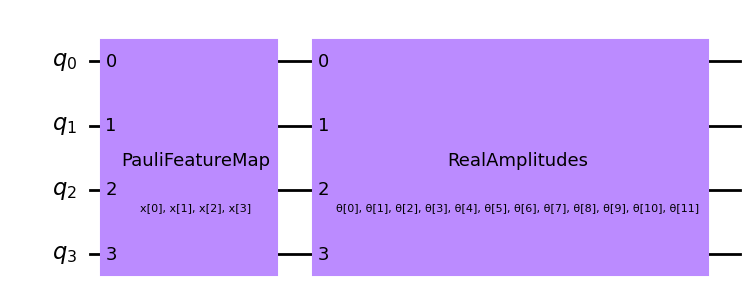

In [37]:
# Visualize the selected circuit
import matplotlib.pyplot as plt
if backend_sel == '1' and selected_embedding is not None:
    # For QLM backend with PennyLane templates
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc_vis, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=4, n_layers=2)
    print("Circuit visualization (PennyLane):")
    fig = qc_vis.draw('mpl')
    plt.show()
elif backend_sel in ('1','2') or (backend_sel == '1' and selected_embedding is None):
    # For QLM/Qiskit backends with Qiskit templates
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
    from qiskit.circuit.library import PauliFeatureMap, ZZFeatureMap, ZFeatureMap
    qc_vis = QuantumCircuit(4)
    if selected_feature_map:
        if selected_feature_map == 'PauliFeatureMap':
            fm = PauliFeatureMap(feature_dimension=4, reps=1)
        elif selected_feature_map == 'ZZFeatureMap':
            fm = ZZFeatureMap(feature_dimension=4, reps=1)
        elif selected_feature_map == 'ZFeatureMap':
            fm = ZFeatureMap(feature_dimension=4, reps=1)
        qc_vis.compose(fm, inplace=True)
    if selected_ansatz == 'RealAmplitudes':
        ans = RealAmplitudes(num_qubits=4, reps=2)
    elif selected_ansatz == 'EfficientSU2':
        ans = EfficientSU2(num_qubits=4, reps=2)
    elif selected_ansatz == 'TwoLocal':
        ans = TwoLocal(num_qubits=4, rotation_blocks='ry', entanglement_blocks='cz', reps=2)
    else:
        # Fallback for unknown ansatz
        print(f"Warning: Unknown ansatz '{selected_ansatz}', using RealAmplitudes as fallback")
        ans = RealAmplitudes(num_qubits=4, reps=2)
    qc_vis.compose(ans, inplace=True)
    print("Circuit visualization (Qiskit):")
    fig = qc_vis.draw('mpl')
    plt.show()
elif backend_sel == '3':
    # For PennyLane -> QLM backend
    from openvqa.interop.pennylane_to_qlm import build_vqe_circuit_qiskit
    qc_vis, _ = build_vqe_circuit_qiskit(selected_embedding, selected_ansatz, n_qubits=4, n_layers=2)
    print("Circuit visualization (PennyLane):")
    fig = qc_vis.draw('mpl')
    plt.show()
else:
    print("No templates selected - circuit visualization skipped.")

## Step 2: Create QAOA Algorithm for MaxCut

Configure QAOA to solve a MaxCut problem on a 4-node graph with p=2 layers.

In [38]:
print(f"  Embedding: {embedding_choice}")

  Embedding: None


In [39]:
print(selected_embedding if 'selected_embedding' in globals() else None)
print(globals().get('selected_feature_map', 'NOT SET'))

None
PauliFeatureMap


In [41]:
feature_map_choice = selected_feature_map if 'selected_feature_map' in globals() else None
embedding_choice = selected_embedding if 'selected_embedding' in globals() else None
print(f"  Embedding: {embedding_choice}")
print(feature_map_choice)

  Embedding: None
PauliFeatureMap


In [45]:
embedding=embedding_choice if embedding_choice is not None else feature_map_choice
embedding

'PauliFeatureMap'

In [ ]:
# Create QAOA algorithm instance (use selected templates and optimizer)
# Debug: check what was selected
print(f"Debug: selected_feature_map = {globals().get('selected_feature_map', 'NOT SET')}")
print(f"Debug: selected_ansatz = {globals().get('selected_ansatz', 'NOT SET')}")
print(f"Debug: selected_optimizer = {globals().get('selected_optimizer', 'NOT SET')}")

feature_map_choice = selected_feature_map if 'selected_feature_map' in globals() else None
embedding_choice = selected_embedding if 'selected_embedding' in globals() else None
ansatz_choice = selected_ansatz if 'selected_ansatz' in globals() else 'StronglyEntanglingLayers'
optimizer_choice = selected_optimizer if 'selected_optimizer' in globals() else 'cobyla'
opt_options = optimizer_options if 'optimizer_options' in globals() else {}

qaoa_algorithm = QAOA(
    problem="maxcut",
    graph_size=4,
    optimizer=optimizer_choice,
    max_iterations=50,
    p=2,
    ansatz=ansatz_choice,
    embedding=embedding_choice if embedding_choice is not None else feature_map_choice,
    optimizer_options=opt_options,
)

print("✓ QAOA algorithm configured")
print(f"  Problem: MaxCut on 4-node graph")
print(f"  QAOA depth (p): 2")
print(f"  Embedding: {embedding_choice if embedding_choice is not None else feature_map_choice}")
print(f"  Ansatz: {ansatz_choice}")
print(f"  Optimizer: {optimizer_choice.upper()}")
if opt_options:
    print(f"  Optimizer options: {opt_options}")

Debug: selected_feature_map = PauliFeatureMap
Debug: selected_ansatz = StronglyEntanglingLayers


## Step 3: Run QAOA Optimization

In [48]:
# Run QAOA optimization
qaoa_results = qaoa_engine.run(qaoa_algorithm)


Executing QAOA algorithm
Building QAOA circuit for maxcut (p=2)...
Running QAOA optimization with cobyla...

VQA OPTIMIZATION RESULTS
Status                       : ✓ Success
Ground-State Energy (Ha)     : -3.1203169789
Optimal Parameters           : {'p_0': 0.09077412072044663, 'p_1': 2.367675607584946, 'p_10': 2.063469527048906, 'p_11': 0.40295740672923247, 'p_12': 1.3757382080441254, 'p_13': 1.0477612532344742, 'p_14': 1.6646371356776255, 'p_15': 0.3730790581893697, 'p_16': 0.5210850196960065, 'p_17': 1.183404509853434, 'p_18': -0.048450295320341896, 'p_19': 2.0464789628511224, 'p_2': -0.052474389909911226, 'p_20': 0.06070117916787515, 'p_21': 0.5031591037690817, 'p_22': 1.1892317136985937, 'p_23': 0.029198593262706997, 'p_3': 0.08342576098451482, 'p_4': 1.5808073161641936, 'p_5': 0.17130835272947414, 'p_6': -0.07753469199609447, 'p_7': 1.5584716941285575, 'p_8': -0.07098881829690544, 'p_9': 0.0335436365108678}
Number of Qubits             : 4
Circuit Depth               : 43
Optim

In [49]:
# Ensure loss/history is attached to `qaoa_results` for plotting cells
res = globals().get('qaoa_results', None)
if res is None:
    print('No qaoa_results object available to attach loss_history.')
else:
    history = None
    # Try common attribute names that may contain per-iteration values
    for attr in ('loss_history','losses','optimizer_history','history','intermediate_energies','intermediate_values') :
        h = getattr(res, attr, None)
        if h is not None and len(h) > 0:
            history = list(h)
            break
    # Try nested optimizer result fields or SciPy OptimizeResult fallback
    if history is None:
        opt = getattr(res, 'optimizer_result', None) or getattr(res, 'opt_result', None)
        if opt is not None:
            # Some optimizers store intermediate values in different attributes
            for oattr in ('history','loss_history','values','allvecs','fun_vals','fun_history') :
                ho = getattr(opt, oattr, None)
                if ho is not None and len(ho) > 0:
                    history = list(ho)
                    break
            # If only final value available, keep that as single-point history
            if history is None and hasattr(opt, 'fun') :
                try:
                    history = [float(opt.fun)]
                except Exception:
                    history = []
    if history is None:
        history = []
    # Attach back to result (use attribute name expected by plotting cells)
    try:
        setattr(res, 'loss_history', history)
        setattr(res, 'intermediate_energies', history)  # keep both names in sync
        globals()['qaoa_results'] = res
        print(f'Attached qaoa_results.loss_history with {len(history)} entries.')
    except Exception as e:
        print('Failed to attach loss_history:', e)

Attached qaoa_results.loss_history with 0 entries.


In [50]:
# Notebook-level instrumentation: re-run PennyLane QNode minimization to collect history for QAOA
import numpy as np
import pennylane as qml
from scipy.optimize import minimize
res = globals().get('qaoa_results', None)
engine = globals().get('qaoa_engine', None)
algo = globals().get('qaoa_algorithm', None)
if res is None or engine is None or algo is None:
    print('Missing qaoa_results, qaoa_engine, or qaoa_algorithm — cannot run instrumentation.')
else:
    print('Running local PennyLane minimization to collect loss history (may differ from QLM run)...')
    # Ensure graph/circuit present
    try:
        qaoa_circuit, qaoa_params = algo.build_circuit()
    except Exception:
        # If build_circuit mutates internal graph, try to ensure graph exists
        if getattr(algo,'graph',None) is None:
            algo._create_maxcut_graph(algo.graph_size)
        qaoa_circuit, qaoa_params = algo.build_circuit()
    # Build PennyLane Hamiltonian (MaxCut)
    coeffs = []
    ops = []
    for u, v in algo.graph.edges():
        weight = algo.graph[u][v].get('weight', 1.0)
        coeffs.append(-weight/2)
        ops.append(qml.PauliZ(wires=u) @ qml.PauliZ(wires=v))
    hamiltonian_pl = qml.Hamiltonian(coeffs, ops)
    n_qubits = algo.graph_size
    p = algo.p
    def qaoa_ansatz(params):
        idx = 0
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for layer in range(p):
            gamma = params[idx]; beta = params[idx+1]
            idx += 2
            for u, v in algo.graph.edges():
                qml.CNOT(wires=[u, v])
                qml.RZ(2 * gamma * algo.graph[u][v].get('weight',1.0), wires=v)
                qml.CNOT(wires=[u, v])
            for q in range(n_qubits):
                qml.RX(2 * beta, wires=q)
    dev = qml.device('default.qubit', wires=n_qubits)
    @qml.qnode(dev)
    def circuit(params):
        qaoa_ansatz(params)
        return qml.expval(hamiltonian_pl)
    n_params = 2 * p
    x0 = np.zeros(n_params)
    history = []
    def cost(p_vec):
        val = float(circuit(p_vec))
        history.append(val)
        return val
    method = algo.optimizer_name.lower()
    method_arg = method.upper() if method in ['cobyla','nelder-mead'] else None
    # Run local minimization (this may be slower, it's meant to collect history)
    try:
        res_min = minimize(cost, x0, method=method_arg, options={'maxiter': algo.max_iterations})
        # Attach history back to qaoa_results
        try:
            setattr(res, 'loss_history', history)
            setattr(res, 'intermediate_energies', history)
            # Optionally update final energy/params from this local run (keep original QLM result too)
            # res.energy = res_min.fun
            # res.optimal_parameters = res_min.x
            globals()['qaoa_results'] = res
            print(f'Collected and attached {len(history)} loss entries to qaoa_results.')
        except Exception as e:
            print('Failed to attach history to qaoa_results:', e)
    except Exception as e:
        print('Local minimization failed:', e)

Running local PennyLane minimization to collect loss history (may differ from QLM run)...
Collected and attached 50 loss entries to qaoa_results.


## Step 4: Display QAOA Results

In [51]:
# Print formatted QAOA results
print(qaoa_results)

# Access individual results
print("\nQAOA Results Summary:")
print(f"MaxCut Value (Approximation)  : {qaoa_results.energy:.6f}")
print(f"Optimal QAOA Parameters       : {qaoa_results.optimal_parameters}")
print(f"Circuit Depth                 : {qaoa_results.circuit_depth}")
print(f"Execution Time               : {qaoa_results.wall_time:.3f} seconds")


VQA OPTIMIZATION RESULTS
Status                       : ✓ Success
Ground-State Energy (Ha)     : -3.1203169789
Optimal Parameters           : {'p_0': 0.09077412072044663, 'p_1': 2.367675607584946, 'p_10': 2.063469527048906, 'p_11': 0.40295740672923247, 'p_12': 1.3757382080441254, 'p_13': 1.0477612532344742, 'p_14': 1.6646371356776255, 'p_15': 0.3730790581893697, 'p_16': 0.5210850196960065, 'p_17': 1.183404509853434, 'p_18': -0.048450295320341896, 'p_19': 2.0464789628511224, 'p_2': -0.052474389909911226, 'p_20': 0.06070117916787515, 'p_21': 0.5031591037690817, 'p_22': 1.1892317136985937, 'p_23': 0.029198593262706997, 'p_3': 0.08342576098451482, 'p_4': 1.5808073161641936, 'p_5': 0.17130835272947414, 'p_6': -0.07753469199609447, 'p_7': 1.5584716941285575, 'p_8': -0.07098881829690544, 'p_9': 0.0335436365108678}
Number of Qubits             : 4
Circuit Depth               : 43
Optimizer                    : cobyla
Function Evaluations        : 0
Converged                    : True
Barren P

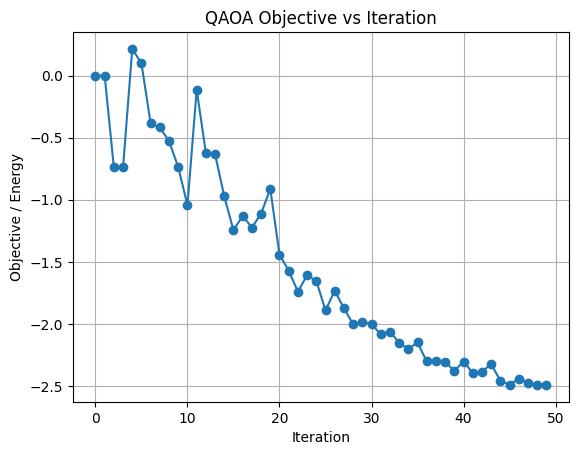

In [52]:
# Visualize results: energy trace (if available) or optimal parameters
import matplotlib.pyplot as plt
import numpy as np

res = globals().get('qaoa_results', None)
if res is None:
    print('No QAOA results available to plot.')
else:
    # Plot energy vs iteration if intermediate_energies exist
    energies = getattr(res, 'intermediate_energies', None)
    if energies and len(energies) > 0:
        energies = np.array(energies)
        plt.figure()
        plt.plot(np.arange(len(energies)), energies, marker='o')
        plt.xlabel('Iteration')
        plt.ylabel('Objective / Energy')
        plt.title('QAOA Objective vs Iteration')
        plt.grid(True)
        plt.show()
    else:
        # Plot optimal parameters
        params = getattr(res, 'optimal_parameters', None)
        if params is None:
            print('No intermediate energies or optimal parameters available to plot.')
        else:
            if isinstance(params, dict):
                names = list(params.keys())
                values = [float(v) for v in params.values()]
            else:
                arr = np.array(params)
                names = [f'p{i}' for i in range(len(arr))]
                values = arr.astype(float).tolist()

            plt.figure(figsize=(8,3))
            plt.bar(names, values)
            plt.ylabel('Parameter value')
            plt.title('Optimal QAOA Parameters')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

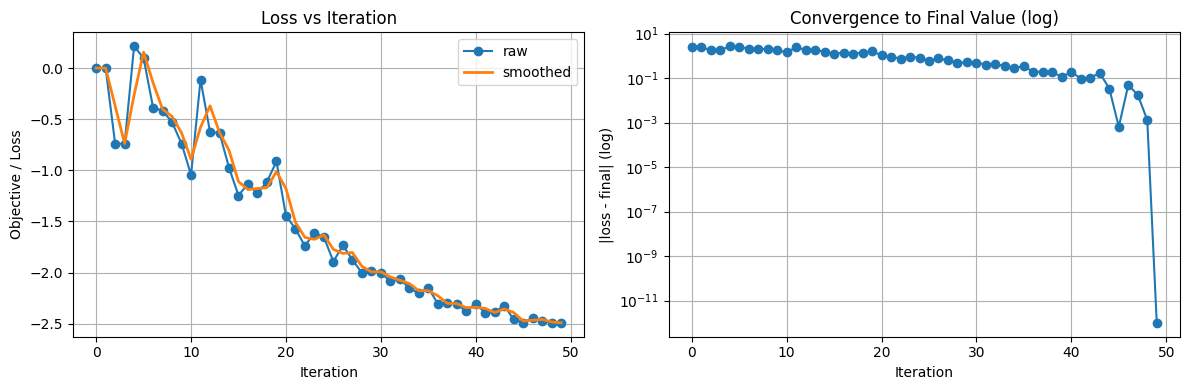

Iterations: 50, Final value: -2.490525e+00, Mean step size: 1.691e-01, Last step: 1.303e-03


In [53]:
# Loss / Convergence Plot for QAOA
import matplotlib.pyplot as plt
import numpy as np

res = globals().get('qaoa_results', None)
if res is None:
    print('No QAOA results available for convergence plots.')
else:
    # Try several common attributes that might contain optimizer history
    history = None
    for attr in ('loss_history','losses','optimizer_history','history','intermediate_energies','intermediate_values'):
        history = getattr(res, attr, None)
        if history is not None and len(history) > 0:
            break
    # Try nested optimizer result
    if history is None:
        opt = getattr(res, 'optimizer_result', None) or getattr(res, 'opt_result', None)
        if opt is not None and hasattr(opt, 'fun'):
            # SciPy optimize result: only final value available
            history = [opt.fun]
    if history is None or len(history) == 0:
        print('No loss/convergence history found on result object.')
    else:
        arr = np.array(history, dtype=float)
        it = np.arange(len(arr))
        # smoothing for visual clarity
        window = max(1, len(arr)//20)
        if window > 1:
            kernel = np.ones(window)/window
            smooth = np.convolve(arr, kernel, mode='same')
        else:
            smooth = arr
        fig, axes = plt.subplots(1,2, figsize=(12,4))
        axes[0].plot(it, arr, '-o', label='raw')
        axes[0].plot(it, smooth, '-', linewidth=2, label='smoothed')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Objective / Loss')
        axes[0].set_title('Loss vs Iteration')
        axes[0].legend()
        axes[0].grid(True)
        # log-scale convergence to final value
        eps = 1e-12
        axes[1].semilogy(it, np.abs(arr - arr[-1]) + eps, '-o')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('|loss - final| (log)')
        axes[1].set_title('Convergence to Final Value (log)')
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
        # simple numeric summary
        if len(arr) > 1:
            diffs = np.abs(np.diff(arr))
            print(f'Iterations: {len(arr)}, Final value: {arr[-1]:.6e}, Mean step size: {np.mean(diffs):.3e}, Last step: {diffs[-1]:.3e}')
        else:
            print(f'Single-point history, final value: {arr[-1]:.6e}')